# UNIVERSIDAD NACIONAL MAYOR DE SAN MARCOS
## Facultad de Ingeniería de Sistemas e Informática (FISI)
### Escuela Profesional de Ingeniería de Sistemas

---

**Asignatura:** Inteligencia Artificial
**Laboratorio:** Semana 2 — Agentes Inteligentes
**Proyecto:** Simulación de un Robot Aspiradora con las Cuatro Arquitecturas Canónicas de Agentes
**Alumnos:**
- Calero Falcon, Gonzalo Manuel
- Huanacuni Gomez, Jean Carlos Josue

**Docente:** Prof. Hugo Vega
**Lima, Perú — 2026**

---

## Índice del laboratorio

1. Planteamiento del problema y contexto de ingeniería
2. Importación de librerías
3. El entorno: una casa representada como grilla de celdas
4. Visualización del entorno inicial
5. Las cuatro arquitecturas de agentes (implementación)
6. Ejecución y comparación de resultados
7. Preguntas conceptuales de autoevaluación
8. Conclusiones
>

# 1. Planteamiento del problema

### 1.1 Pregunta gancho
Un robot aspiradora doméstico (como una Roomba) tiene que limpiar toda una casa
sin que nadie le diga paso a paso qué hacer. **¿Cómo decide, en cada instante,
si debe aspirar o moverse, y hacia dónde?** La respuesta depende de qué tan
"inteligente" sea su arquitectura interna — y eso es exactamente lo que vamos a
programar y comparar en este laboratorio.

### 1.2 Contexto del problema
Siguiendo el ejemplo clásico de Russell & Norvig (2021), modelamos una casa como
una **grilla de habitaciones**. Algunas celdas están sucias y otras limpias. Un
agente aspiradora debe percibir su entorno, decidir una acción y ejecutarla,
repitiendo este ciclo hasta que toda la casa quede limpia.

### 1.3 Enunciado formal del problema
> *"Simular un mismo entorno doméstico con cuatro arquitecturas distintas de
> agente (reflejo simple, reflejo basado en modelos, basado en objetivos y
> basado en utilidad), midiendo cuántas acciones necesitó cada una para dejar
> la casa limpia y qué tan eficiente fue su rendimiento."*

### 1.4 Especificación REAS / PEAS del agente aspiradora

| Componente | Especificación en este laboratorio |
|---|---|
| **R — Rendimiento** | +10 puntos por cada celda sucia que limpia, −1 punto por cada acción (moverse o aspirar) que ejecuta |
| **E — Entorno** | Una grilla de 4×4 celdas (una casa simplificada); algunas están sucias al inicio |
| **A — Actuadores** | Moverse (Norte, Sur, Este, Oeste) y Aspirar |
| **S — Sensores** | Según la arquitectura: solo "¿la celda actual está sucia?" (reflejo simple) o el mapa completo de suciedad (agentes con modelo/objetivo/utilidad) |

### 1.5 El ciclo Percepción-Decisión-Acción
En cada paso de la simulación, el agente: **(1)** percibe el estado de su celda
actual (o de todo el mundo, según su arquitectura), **(2)** decide una acción
según sus reglas internas, y **(3)** ejecuta esa acción, lo que cambia el
entorno o su posición para el siguiente ciclo — exactamente el bucle descrito
en la sección 3.2 del informe de la Semana 2.

# 2. Importación de librerías

Este laboratorio no necesita Machine Learning: los "agentes" son simplemente
funciones de Python con distintas reglas de decisión. Usamos `random` para
generar la suciedad inicial de forma reproducible, y `pandas`/`matplotlib` para
mostrar tablas y gráficos.

In [ ]:
import random                     # Generar el entorno inicial de forma reproducible
import pandas as pd               # Tabla comparativa de resultados
import matplotlib.pyplot as plt   # Gráficos

plt.rcParams['axes.grid'] = False
AZUL, ROJO, VERDE = '#2E86AB', '#E63946', '#5C946E'

print('[OK] Entorno de Python inicializado correctamente.')

[OK] Entorno de Python inicializado correctamente.


# 3. El entorno: una casa representada como grilla de celdas

Representamos la casa como una grilla de `FILAS x COLUMNAS` celdas. Cada celda
puede estar **sucia** (`True`) o **limpia** (`False`). El agente siempre
empieza en la esquina superior izquierda, la celda `(0, 0)`.

In [ ]:
FILAS, COLUMNAS = 4, 4
PROB_SUCIEDAD = 0.35   # probabilidad de que una celda empiece sucia
POSICION_INICIAL = (0, 0)

random.seed(7)  # semilla fija: así todos obtenemos la misma casa "sucia" al ejecutar

def generar_mundo():
    '''Crea un diccionario {(fila, columna): sucia?} representando la casa.'''
    return {(f, c): (random.random() < PROB_SUCIEDAD)
            for f in range(FILAS) for c in range(COLUMNAS)}

mundo_inicial = generar_mundo()
total_sucias = sum(mundo_inicial.values())
print(f'[OK] Casa generada: {total_sucias} de {FILAS * COLUMNAS} celdas empiezan sucias.')

[OK] Casa generada: 9 de 16 celdas empiezan sucias.


### 3.1 Funciones auxiliares de movimiento
Estas funciones no son parte de la "inteligencia" del agente: son solo la física
del mundo (qué movimientos son válidos y cómo se traza una ruta entre dos
celdas). Las usarán varias arquitecturas de agente.

In [ ]:
def vecinos_validos(posicion):
    '''Devuelve la lista de (accion, nueva_posicion) posibles desde una celda.'''
    f, c = posicion
    opciones = []
    if f > 0:            opciones.append(('Norte', (f - 1, c)))
    if f < FILAS - 1:     opciones.append(('Sur',   (f + 1, c)))
    if c > 0:            opciones.append(('Oeste', (f, c - 1)))
    if c < COLUMNAS - 1:  opciones.append(('Este',  (f, c + 1)))
    return opciones

def distancia_manhattan(a, b):
    '''Cuántos movimientos como mínimo hacen falta para ir de a hasta b.'''
    return abs(a[0] - b[0]) + abs(a[1] - b[1])

def ruta_hacia(origen, destino):
    '''Secuencia de celdas para ir de origen a destino (primero filas, luego columnas).'''
    ruta = []
    f, c = origen
    ff, cc = destino
    while f != ff:
        f += 1 if ff > f else -1
        ruta.append((f, c))
    while c != cc:
        c += 1 if cc > c else -1
        ruta.append((f, c))
    return ruta

# 4. Visualización del entorno inicial

Antes de simular a los agentes, veamos cómo luce la casa: qué celdas están
sucias (café) y cuáles ya están limpias (celeste).

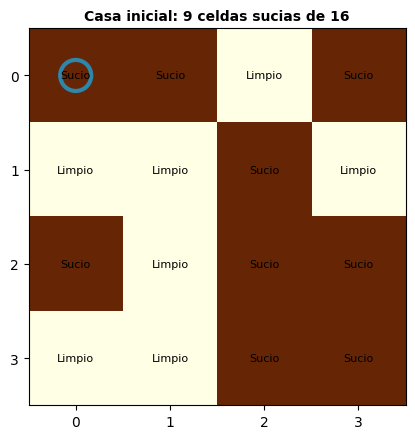

In [ ]:
def dibujar_mundo(mundo, titulo, posicion_agente=None, ax=None):
    matriz = [[1 if mundo[(f, c)] else 0 for c in range(COLUMNAS)] for f in range(FILAS)]
    mostrar = ax is None
    if ax is None:
        fig, ax = plt.subplots(figsize=(4.5, 4.5))
    ax.imshow(matriz, cmap='YlOrBr', vmin=0, vmax=1)
    for f in range(FILAS):
        for c in range(COLUMNAS):
            ax.text(c, f, 'Sucio' if mundo[(f, c)] else 'Limpio',
                    ha='center', va='center', fontsize=8)
    if posicion_agente is not None:
        ax.scatter(*posicion_agente[::-1], s=500, facecolors='none',
                   edgecolors=AZUL, linewidths=3)
    ax.set_title(titulo, fontweight='bold', fontsize=10)
    ax.set_xticks(range(COLUMNAS)); ax.set_yticks(range(FILAS))
    if mostrar:
        plt.tight_layout()
        plt.show()

dibujar_mundo(mundo_inicial, f'Casa inicial: {total_sucias} celdas sucias de {FILAS * COLUMNAS}',
              posicion_agente=POSICION_INICIAL)

**¿Qué nos dice este gráfico?**
El círculo azul marca dónde arranca el agente aspiradora, en la esquina superior
izquierda. Las celdas color café son las que están sucias al comenzar la
simulación. Este es el **mismo mundo inicial** que usaremos para probar las
cuatro arquitecturas de agente, así la comparación es justa: todas parten
exactamente de la misma casa sucia.

# 5. Las cuatro arquitecturas de agentes

Implementamos las cuatro arquitecturas canónicas descritas en la sección 5 del
informe de la Semana 2. Las dos primeras son **ciegas al mapa completo**: solo
saben si la celda donde están parados está sucia. Las dos últimas asumen un
**entorno totalmente observable** (el agente conoce el mapa completo de
suciedad desde el inicio), lo que les permite planificar.

### 5.1 Agente de Reflejo Simple
No tiene memoria de nada. Regla: *"si la celda está sucia, aspira; si no, muévete
a una celda vecina al azar"*. Como no recuerda qué celdas ya visitó, puede
revisitar la misma celda muchas veces — la limitación descrita en la sección
5.1 del informe.

In [ ]:
def agente_reflejo_simple(mundo, limite_acciones=300, semilla=42):
    mundo = dict(mundo)  # copia: cada agente limpia su propia versión del mundo
    posicion = POSICION_INICIAL
    acciones = 0
    limpiadas = 0
    aleatorio = random.Random(semilla)

    while acciones < limite_acciones:
        if mundo[posicion]:                       # Percepción: ¿esta celda está sucia?
            mundo[posicion] = False                # Acción: Aspirar
            limpiadas += 1
            acciones += 1
        else:
            if not any(mundo.values()):             # ya no queda nada sucio en la casa
                break
            _, posicion = aleatorio.choice(vecinos_validos(posicion))  # Acción: moverse al azar
            acciones += 1

    return {'acciones': acciones, 'limpiadas': limpiadas,
            'todo_limpio': not any(mundo.values())}

### 5.2 Agente de Reflejo Basado en Modelos
Mantiene en su memoria un **plan de barrido sistemático** (recorre la casa en
zig-zag, fila por fila) para no repetir celdas innecesariamente. No conoce de
antemano cuáles celdas están sucias — solo evita perder el tiempo revisitando
lugares donde ya estuvo, gracias a su modelo interno del recorrido.

In [ ]:
def agente_reflejo_con_modelo(mundo):
    mundo = dict(mundo)
    acciones = 0
    limpiadas = 0

    # El "modelo interno" del agente: un recorrido en zig-zag que cubre toda la casa
    recorrido = []
    for f in range(FILAS):
        columnas = range(COLUMNAS) if f % 2 == 0 else range(COLUMNAS - 1, -1, -1)
        recorrido.extend((f, c) for c in columnas)

    posicion = recorrido[0]
    if mundo[posicion]:
        mundo[posicion] = False
        limpiadas += 1
        acciones += 1

    for siguiente in recorrido[1:]:
        acciones += 1                 # Acción: moverse a la siguiente celda del plan
        posicion = siguiente
        if mundo[posicion]:            # Percepción: ¿esta celda está sucia?
            mundo[posicion] = False    # Acción: Aspirar
            limpiadas += 1
            acciones += 1

    return {'acciones': acciones, 'limpiadas': limpiadas,
            'todo_limpio': not any(mundo.values())}

### 5.3 Agente Basado en Objetivos
Su meta es clara: *"dejar limpias todas las celdas sucias"*. Como conoce el mapa
completo, arma una lista de las celdas-meta (las sucias) y las visita **en el
orden en que aparecen** en la casa, sin preocuparse por si el recorrido es el
más corto — solo le importa **llegar** a cada meta, no qué tan eficiente sea el
camino (la visión "binaria" descrita en la sección 10.4 del informe).

In [ ]:
def agente_basado_en_objetivos(mundo):
    mundo = dict(mundo)
    posicion = POSICION_INICIAL
    acciones = 0
    limpiadas = 0

    metas = [celda for celda in mundo if mundo[celda]]   # celdas sucias, en orden de descubrimiento

    for meta in metas:
        if not mundo[meta]:            # pudo haberse "limpiado" si coincidiera con otra meta
            continue
        for paso in ruta_hacia(posicion, meta):
            posicion = paso
            acciones += 1               # Acción: moverse un paso hacia la meta
        mundo[posicion] = False
        limpiadas += 1
        acciones += 1                   # Acción: Aspirar

    return {'acciones': acciones, 'limpiadas': limpiadas,
            'todo_limpio': not any(mundo.values())}

### 5.4 Agente Basado en Utilidad
Comparte la meta del agente anterior, pero además **optimiza cómo la
alcanza**: en cada paso calcula la utilidad de ir a cada celda sucia
(recompensa de limpiarla menos el costo de la distancia) y elige siempre la
celda sucia más cercana. Es el mismo objetivo, pero resuelto con menos
desplazamiento — el "trade-off" entre beneficio y costo descrito en la sección
5.4 del informe.

In [ ]:
def agente_basado_en_utilidad(mundo):
    mundo = dict(mundo)
    posicion = POSICION_INICIAL
    acciones = 0
    limpiadas = 0

    while True:
        sucias = [celda for celda in mundo if mundo[celda]]
        if not sucias:
            break
        # Utilidad = recompensa fija de limpiar - costo de la distancia; se elige la mejor
        meta = min(sucias, key=lambda celda: distancia_manhattan(posicion, celda))
        for paso in ruta_hacia(posicion, meta):
            posicion = paso
            acciones += 1
        mundo[posicion] = False
        limpiadas += 1
        acciones += 1

    return {'acciones': acciones, 'limpiadas': limpiadas,
            'todo_limpio': not any(mundo.values())}

# 6. Ejecución y comparación de resultados

Ejecutamos las cuatro arquitecturas sobre **exactamente la misma casa sucia**
y calculamos el rendimiento de cada una con la fórmula definida en la sección
1.4: `+10` por celda limpiada y `-1` por cada acción ejecutada.

In [ ]:
agentes = {
    'Reflejo simple':        lambda: agente_reflejo_simple(mundo_inicial),
    'Reflejo con modelo':    lambda: agente_reflejo_con_modelo(mundo_inicial),
    'Basado en objetivos':   lambda: agente_basado_en_objetivos(mundo_inicial),
    'Basado en utilidad':    lambda: agente_basado_en_utilidad(mundo_inicial),
}

resultados = []
for nombre, funcion in agentes.items():
    r = funcion()
    rendimiento = 10 * r['limpiadas'] - 1 * r['acciones']
    resultados.append({
        'Arquitectura': nombre,
        'Acciones ejecutadas': r['acciones'],
        'Celdas limpiadas': r['limpiadas'],
        '¿Casa 100% limpia?': 'Sí' if r['todo_limpio'] else 'No',
        'Rendimiento (10*limpiadas - acciones)': rendimiento,
    })

tabla_resultados = pd.DataFrame(resultados)
tabla_resultados

,Arquitectura,Acciones ejecutadas,Celdas limpiadas,¿Casa 100% limpia?,Rendimiento (10*limpiadas - acciones)
0,Reflejo simple,83,9,Sí,7
1,Reflejo con modelo,24,9,Sí,66
2,Basado en objetivos,23,9,Sí,67
3,Basado en utilidad,21,9,Sí,69


**¿Qué nos dice esta tabla?**
Las cuatro arquitecturas logran dejar la casa limpia, pero con un esfuerzo muy
distinto. El **reflejo simple** necesita muchísimas más acciones porque
deambula sin memoria y repite celdas por pura casualidad. El **reflejo con
modelo** ya es mucho más eficiente porque sigue un plan de recorrido sin
repetirse. El **agente basado en objetivos** hace aún menos movimientos porque
ignora las celdas ya limpias y solo va a las sucias — aunque sin optimizar el
camino. El **agente basado en utilidad** es el más eficiente de todos, porque
en cada paso elige racionalmente la celda sucia que le conviene más limpiar
primero.

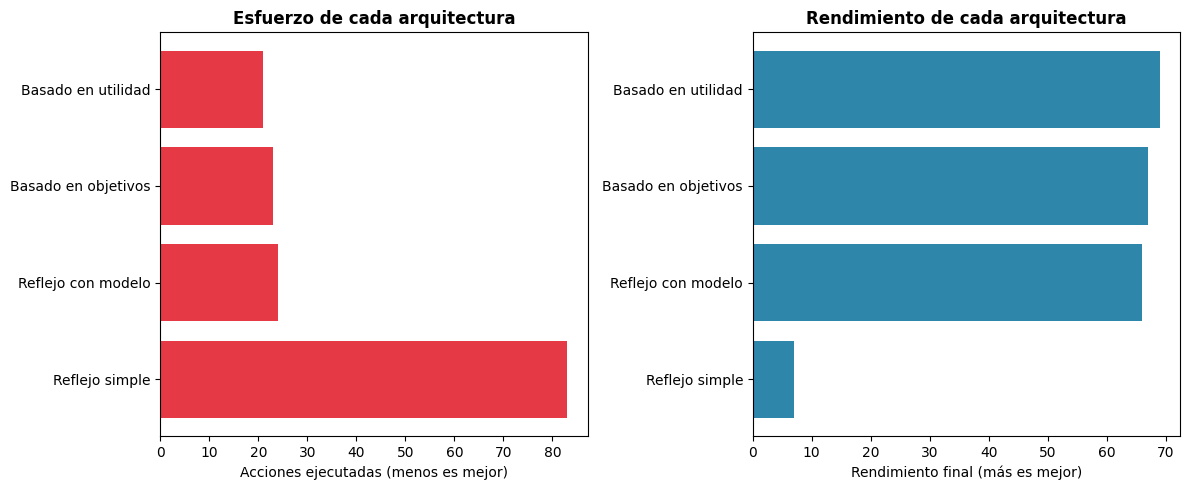

In [ ]:
# ---------------------------------------------------------------------------
# 6.1 Gráfico comparativo: acciones ejecutadas y rendimiento final
# ---------------------------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.barh(tabla_resultados['Arquitectura'], tabla_resultados['Acciones ejecutadas'], color=ROJO)
ax1.set_xlabel('Acciones ejecutadas (menos es mejor)')
ax1.set_title('Esfuerzo de cada arquitectura', fontweight='bold')

ax2.barh(tabla_resultados['Arquitectura'],
          tabla_resultados['Rendimiento (10*limpiadas - acciones)'], color=AZUL)
ax2.set_xlabel('Rendimiento final (más es mejor)')
ax2.set_title('Rendimiento de cada arquitectura', fontweight='bold')

plt.tight_layout()
plt.show()

**¿Qué nos dice este gráfico?**
El panel izquierdo confirma que el reflejo simple es, por lejos, el que más
"trabaja" para lograr el mismo resultado. El panel derecho traduce ese esfuerzo
en rendimiento: mientras más memoria, planificación y razonamiento sobre costos
tiene un agente, **mayor es su rendimiento neto** con la misma tarea — esta es,
en una sola imagen, la razón de ingeniería por la cual los sistemas modernos
prefieren arquitecturas basadas en objetivos y en utilidad, y no reflejos
simples, para tareas del mundo real.

# 7. Preguntas  de reflexión

**1. ¿Por qué el agente de reflejo simple necesitó tantas más acciones que los
demás, si al final las cuatro arquitecturas dejaron la casa limpia?**
Porque no tiene memoria de qué celdas ya visitó: cada decisión depende
únicamente de lo que percibe en ese instante. Al moverse al azar cuando una
celda ya está limpia, puede volver a pasar por el mismo lugar una y otra vez,
desperdiciando acciones (y batería) sin ningún beneficio.

**2. ¿Qué papel cumple el "modelo interno" en el agente de reflejo basado en
modelos?**
Le permite recordar un plan de recorrido (el zig-zag) aunque sus sensores solo
le digan si la celda actual está sucia. Gracias a ese modelo evita repetir
celdas, aunque igual tiene que visitarlas todas porque no sabe de antemano
cuáles están sucias.

**3. ¿Cuál es la diferencia real entre el agente basado en objetivos y el
agente basado en utilidad, si ambos terminan limpiando exactamente las mismas
celdas?**
El agente basado en objetivos solo verifica si cumplió la meta (limpiar todo),
sin importarle demasiado el orden ni la distancia recorrida. El agente basado
en utilidad, en cambio, evalúa en cada paso el costo de cada alternativa y
elige la que maximiza el beneficio neto (limpiar lo más posible gastando lo
menos posible), lo que explica por qué terminó con menos acciones.

**4. Si la casa fuera mucho más grande (por ejemplo, 50×50 celdas) y con pocas
celdas sucias, ¿qué arquitectura sería más eficiente y por qué?**
El agente basado en utilidad, porque solo se desplaza hacia las celdas
realmente sucias más cercanas. El agente de reflejo con modelo tendría que
recorrer las 2500 celdas igual, aunque casi todas estén limpias, lo cual sería
muy poco eficiente en comparación.

**5. ¿Qué tendría que cambiar en este código si el entorno fuera solo
parcialmente observable (el agente no conociera el mapa completo de
suciedad)?**
Los agentes basado en objetivos y basado en utilidad ya no podrían armar su
lista de metas de entrada porque no sabrían dónde está la suciedad. Tendrían
que explorar el entorno como el agente de reflejo con modelo, actualizando su
mapa interno celda por celda a medida que lo van percibiendo, y recién
planificar sobre lo que ya han descubierto.

# 8. Conclusiones
### 8.1 Conclusiones del laboratorio
1. **Todas las arquitecturas resuelven la tarea, pero no con la misma
   eficiencia.** La diferencia entre ellas no está en si "funcionan" o no, sino
   en cuánto le cuesta a cada una lograr el mismo resultado.
2. **La memoria y la planificación son las que marcan la diferencia real.** El
   salto de rendimiento más grande ocurre al pasar de un agente sin memoria
   (reflejo simple) a uno con un modelo interno del mundo.
3. **La utilidad es la evolución natural del objetivo.** Un agente basado en
   objetivos ya es mucho mejor que uno reflejo, pero un agente basado en
   utilidad demuestra que "llegar a la meta" y "llegar a la meta de la mejor
   forma posible" son ideas distintas y ambas importan en ingeniería.

### 8.2 Aplicaciones reales de esta misma idea
- **Robots aspiradora domésticos** (Roomba y similares), que en la práctica
  combinan sensores LiDAR con planificación de rutas para no repetir zonas.
- **Agentes de fiscalización de compras públicas (SEACE)**, descritos en la
  sección 6 del informe: un modelo interno (grafo de vínculos societarios) más
  una función de utilidad que pondera el riesgo frente al impacto social.
- **Drones agrícolas y robots de almacén**, que planifican rutas de cobertura
  o de entrega optimizando distancia y tiempo, igual que nuestro agente basado
  en utilidad.



### 8.3 Referencias
- Russell, S., & Norvig, P. (2021). *Artificial Intelligence: A Modern
  Approach* (4.ª ed.). Pearson.
- Franklin, S., & Graesser, A. (1996). *Is it an Agent, or just a Program?: A
  Taxonomy for Autonomous Agents*. En Proceedings of the Third International
  Workshop on Agent Theories, Architectures, and Languages (pp. 21–35).
  Springer-Verlag.
- Wooldridge, M. (2009). *An Introduction to MultiAgent Systems* (2.ª ed.).
  John Wiley & Sons.